In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

orders=pd.read_csv('orders.csv')
customers=pd.read_csv('customers.csv')
order_items=pd.read_csv('order_items.csv')
products=pd.read_csv('products.csv')
payments=pd.read_csv('payments.csv')


In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


# data cleaning starts from here

In [5]:
orders.info()
customers.info()
order_items.info()
products.info()
payments.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        

In [6]:
#1
#finding null values

print(orders.isnull().sum())     #checking null values
print(customers.isnull().sum())
print(order_items.isnull().sum())
print(products.isnull().sum())
print(payments.isnull().sum())


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64
order_id     

In [7]:
#1.2

# handling missing /nullvalues # i handled missing values using dropna for clean analysis
products.dropna(inplace=True)   #products table missing / none values droped
orders.dropna(inplace=True)
customers.dropna(inplace=True)
order_items.dropna(inplace=True)
payments.dropna(inplace=True)


In [8]:
#2.1 - 2.2 remove duplicates
#check one by one table of duplicates,& count(duplicates present)if found drop_duplicated in original 
#1
print(orders.duplicated().sum())  # 0 duplicates
orders.drop_duplicates(inplace=True) 

#2
print(customers.duplicated().sum()) #0 duplicates
customers.drop_duplicates(inplace=True)

#3
print(order_items.duplicated().sum())
order_items.drop_duplicates(inplace=True)

#4
print(products.duplicated().sum())
products.drop_duplicates(inplace=True)

#5
print(payments.duplicated().sum())
payments.drop_duplicates(inplace=True)


# duplicates removed (if found)


0
0
0
0
0


In [9]:
#3 converting date columns
orders['order_purchase_timestamp']=pd.to_datetime(orders['order_purchase_timestamp'])

**optional**

In [10]:
# for all colun check and make it         
orders.columns     # see all columns are in lower or not 
orders.columns.str.lower()   # or else make it lower

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [11]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


# **you can say in interview**
Checked data structure using info()
handled missing values
removed duplicated
converted date columns
prepared clean data set

# step 3 **data merging**

in this we have to make table all into one
**(we need one final table )**

In [12]:
orders.head(3)
products.head(1)
order_items.head(2)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93


In [13]:
#merged
#  orders -> customers   (customer_id <--> customer_id)

df = orders.merge(customers,on='customer_id')

In [14]:
#2.merge common column
#merge= orders + cutomers (order_id)  -->   order_items(order_id)
df= df.merge(order_items,on='order_id')

In [15]:
#3 merge common column
#merge= order + customers + order_items (product_id) --> products (product_id) 
df=df.merge(products,on='product_id')

In [16]:
#4 merge column
# merge= orders + customers + order_items + products (order_id) --> payments (order_id)
df=df.merge(payments,on='order_id')

In [17]:
# all table merged through common column
df.head()
df.shape

(113390, 30)

# now i have full dataset 
**i used INNER JOIN using pandas merge on  common keys like customer_id and order_id**

In [18]:
#check columns 
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'payment_sequential', 'payment_type', 'payment_installments',
       'payment_value'],
      dtype='str')

**data integration - Combining data from multiple sources into one single data set**

# STEP-4 FEATURE ENGINEERING
CREATING NEW USEFULL COLUMNS

In [19]:
#4.1 Extract month (for sales trend)
df['order_month']=df['order_purchase_timestamp'].dt.month

In [20]:
#extract year
df['order_year']=df['order_purchase_timestamp'].dt.year

In [21]:
#creating total price
df['total_price'] = df['price']+df['freight_value'] # important for revenue calculation & business insights

In [22]:
#calculate order value per order
order_value=df.groupby('order_id')['total_price'].sum().reset_index()


In [23]:
#customer Total Spend
customer_spend=df.groupby('customer_id')['total_price'].sum().reset_index()

In [24]:
#Order Count per customer
order_count=df.groupby('customer_id')['order_id'].nunique().reset_index()

# this is Real Analytic 
**I performed feature engineering by creating new variables like order_month, total_price, and customer-level metrics to enhance business analysis**

# STEP-5 EDA (Exploratory Data Analysis)

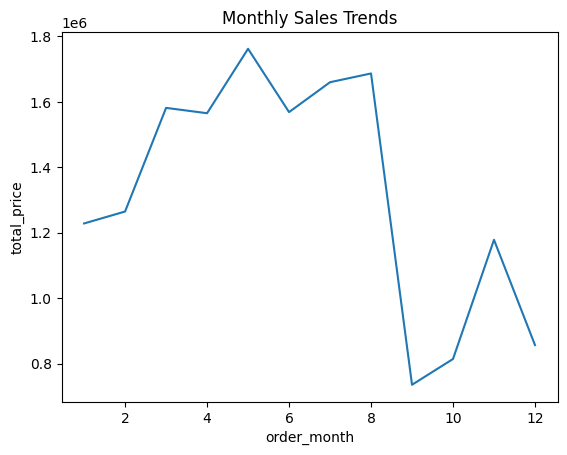

In [25]:
#5.1 monthly sales Trend
monthly_sales=df.groupby('order_month')['total_price'].sum().reset_index()

sns.lineplot(data=monthly_sales,x='order_month',y='total_price')
plt.title("Monthly Sales Trends")
plt.show()

**Insights: Sales vary across months, indicating seasonal demand pattern**

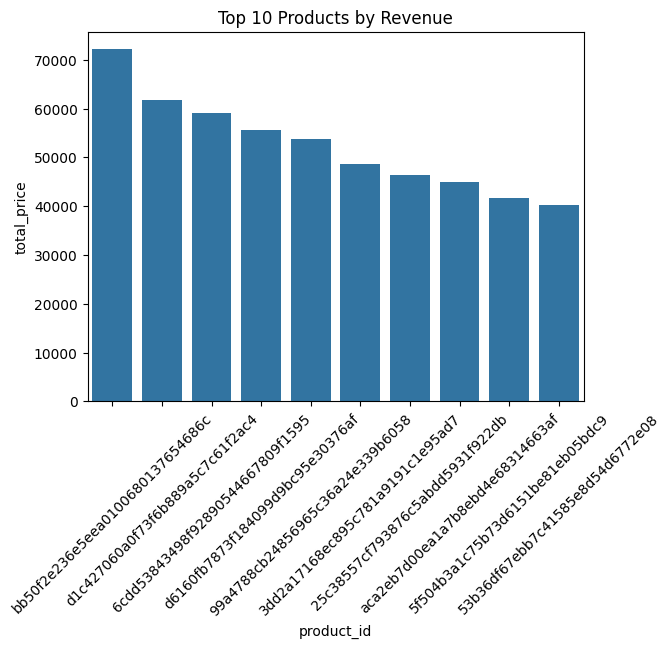

In [26]:
#5.2 top 10 products by revenue
top_products=df.groupby('product_id')['total_price'].sum().reset_index()
top_products=top_products.sort_values(by='total_price',ascending=False).head(10)

plt.figure()
sns.barplot(data=top_products,x='product_id', y='total_price')
plt.title("Top 10 Products by Revenue")
plt.xticks(rotation=45)
plt.show()

**Insights: Top Products Contribute a major share of total revenue**

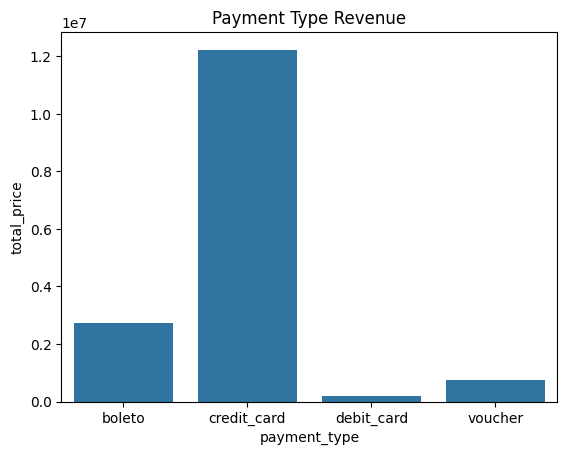

In [27]:
#5.3 Revenue by Payment Type
payment=df.groupby('payment_type')['total_price'].sum().reset_index()

sns.barplot(data=payment,x='payment_type', y='total_price')
plt.title("Payment Type Revenue")
plt.show()

**Insights: Most customers prefer specific payment methods like credit card**

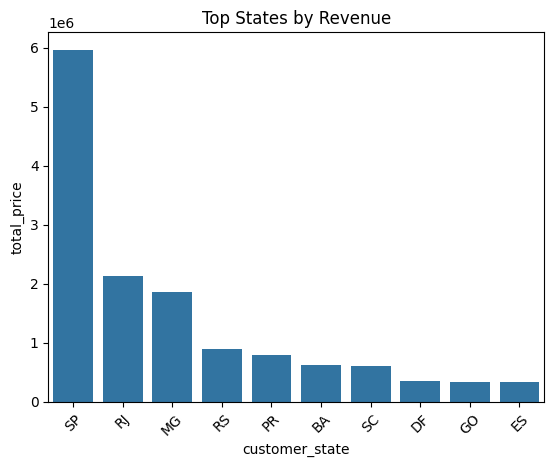

In [28]:
#step 5.4  Orders by State
state_sales = df.groupby('customer_state')['total_price'].sum().reset_index()
state_sales=state_sales.sort_values(by='total_price',ascending=False).head(10)

sns.barplot(data=state_sales,x='customer_state',y='total_price')
plt.title("Top States by Revenue")
plt.xticks(rotation=45)
plt.show()

**Insights: Top states contribute significantly higher revenue compared to others, Indicating regional concentration of sales**

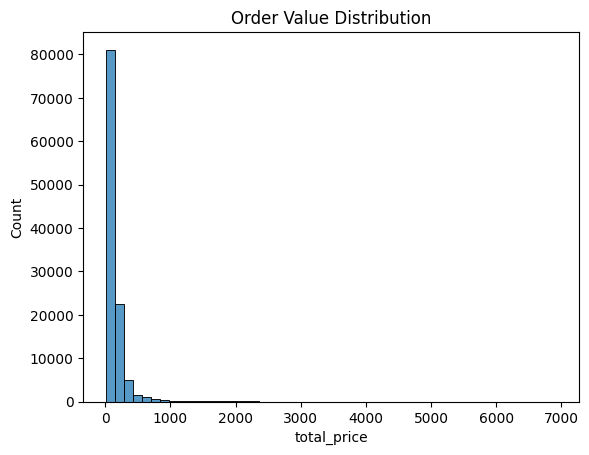

In [29]:
#5.5 Distribution of order value  (HISTOGRAM)
sns.histplot(df['total_price'],bins=50)
plt.title("Order Value Distribution")
plt.show()

**Insights: Most orders fall under a specific price range**

**Interview explanation:**  **i performed exploratory data analysis using Pandas and map**

In [30]:
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,payment_sequential,payment_type,payment_installments,payment_value,order_month,order_year,total_price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,1,credit_card,1,18.12,10,2017,38.71
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,3,voucher,1,2.00,10,2017,38.71
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,2,voucher,1,18.59,10,2017,38.71
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,19.0,13.0,19.0,1,boleto,1,141.46,7,2018,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,24.0,19.0,21.0,1,credit_card,3,179.12,8,2018,179.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113385,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,da62f9e57a76d978d02ab5362c509660,11722,...,40.0,10.0,40.0,1,credit_card,3,195.00,2,2018,195.00
113386,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,737520a9aad80b3fbbdad19b66b37b30,45920,...,32.0,90.0,22.0,1,credit_card,5,271.01,8,2017,271.01
113387,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,...,20.0,20.0,20.0,1,credit_card,4,441.16,1,2018,220.58
113388,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,5097a5312c8b157bb7be58ae360ef43c,28685,...,20.0,20.0,20.0,1,credit_card,4,441.16,1,2018,220.58


In [31]:
df.to_csv("Ecommerce_data.csv",index=False)

In [35]:
df=pd.read_csv('Ecommerce_data.csv')
